In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [31]:
gwh = pd.read_csv("./weight-height.csv")
gwh.sample(10)

,Gender,Height,Weight
4089,Male,68.074736,187.335137
5354,Female,61.432400,127.844520
3139,Male,63.720260,156.769607
5684,Female,62.633005,127.536665
9098,Female,61.744614,130.301968
9982,Female,69.868511,177.992066
5887,Female,67.413064,146.090041
5517,Female,59.390280,123.830413
8189,Female,65.755948,137.471104
8713,Female,65.991977,155.414139


In [32]:
gwh["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\3633758841.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gwh["Height"])


<Axes: xlabel='Height', ylabel='Density'>

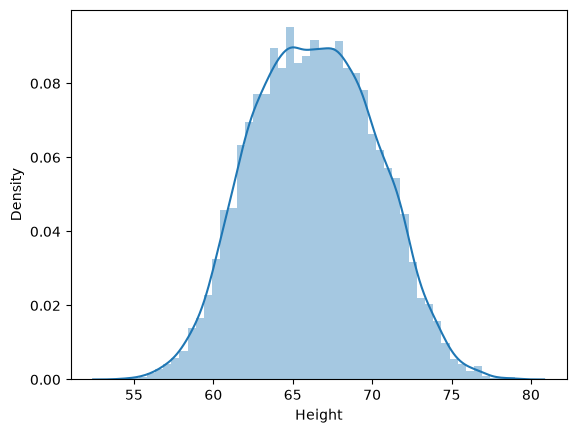

In [33]:
sns.distplot(gwh["Height"])

<Axes: xlabel='Height'>

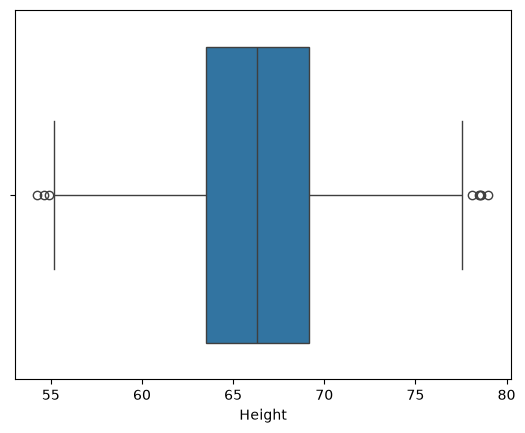

In [34]:
sns.boxplot(x= gwh["Height"])

In [35]:
upper_bound = gwh["Height"].quantile(0.99)
lower_bound = gwh["Height"].quantile(0.01)

In [36]:
gwh[(gwh["Height"] <= lower_bound) | (gwh["Height"] >= upper_bound)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# TRIMMING


In [37]:
trimmed_gwh = gwh.drop(gwh[(gwh["Height"] <= lower_bound) | (gwh["Height"] >= upper_bound)].index)

In [39]:
trimmed_gwh[(trimmed_gwh["Height"] <= lower_bound) | (trimmed_gwh["Height"] >= upper_bound)]

,Gender,Height,Weight


In [40]:
gwh.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [41]:
trimmed_gwh.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\3356327723.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gwh["Height"], color= "red", hist= True)
C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\3356327723.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(trimmed_gwh["Height"], color=

<Axes: title={'center': 'Trimmed'}, ylabel='Density'>

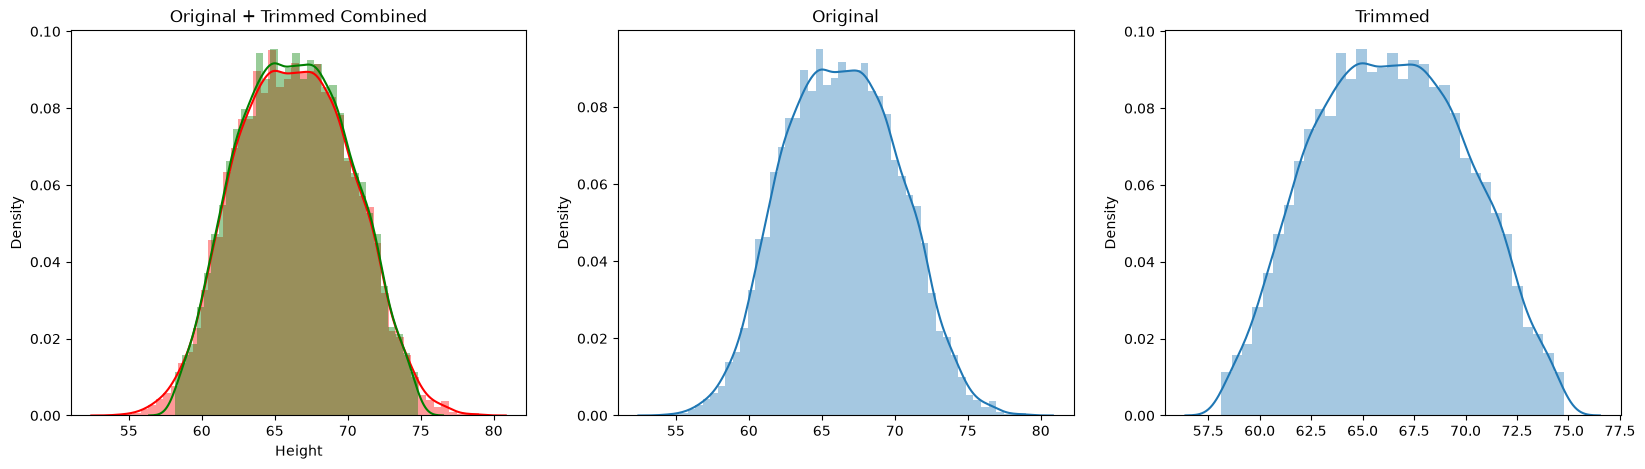

In [51]:
plt.figure(figsize= (20, 5))

plt.subplot(131)
plt.title("Original + Trimmed Combined")
sns.distplot(gwh["Height"], color= "red", hist= True)
sns.distplot(trimmed_gwh["Height"], color= "green", hist= True)

plt.subplot(132)
plt.title("Original")
sns.distplot(x= gwh["Height"])

plt.subplot(133)
plt.title("Trimmed")
sns.distplot(x= trimmed_gwh["Height"])

<Axes: title={'center': 'Trimmed'}, xlabel='Height'>

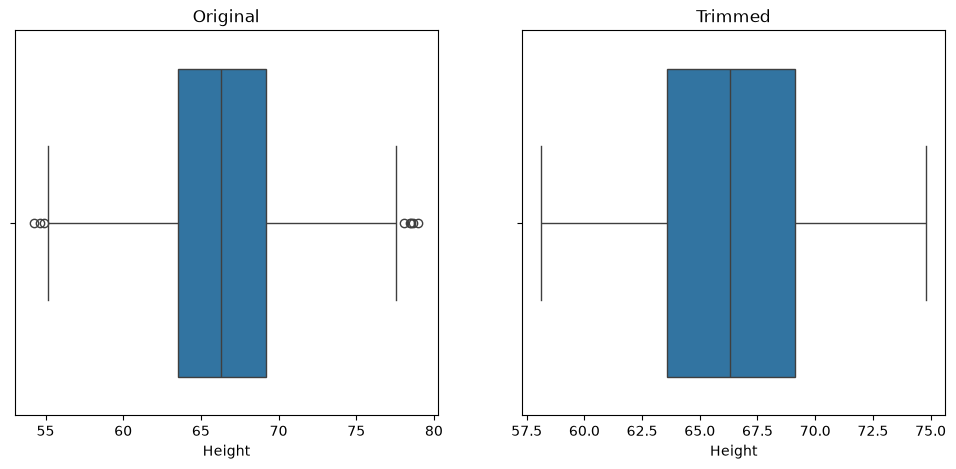

In [48]:
plt.figure(figsize= (12, 5))

plt.subplot(121)
plt.title("Original")
sns.boxplot(x= gwh["Height"])

plt.subplot(122)
plt.title("Trimmed")
sns.boxplot(x= trimmed_gwh["Height"])

# CAPPING $( WINSORIZATION )$

In [53]:
capped_gwh = gwh.copy()

capped_gwh["Height"] = np.where(
    gwh["Height"] <= lower_bound,
    lower_bound,
    np.where(
        gwh["Height"] >= upper_bound,
        upper_bound,
        gwh["Height"]
    )
)

In [54]:
capped_gwh["Height"].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\2078023789.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gwh["Height"], color= "red", hist= True)
C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\2078023789.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(capped_gwh["Height"], color= 

<Axes: title={'center': 'Capped'}, ylabel='Density'>

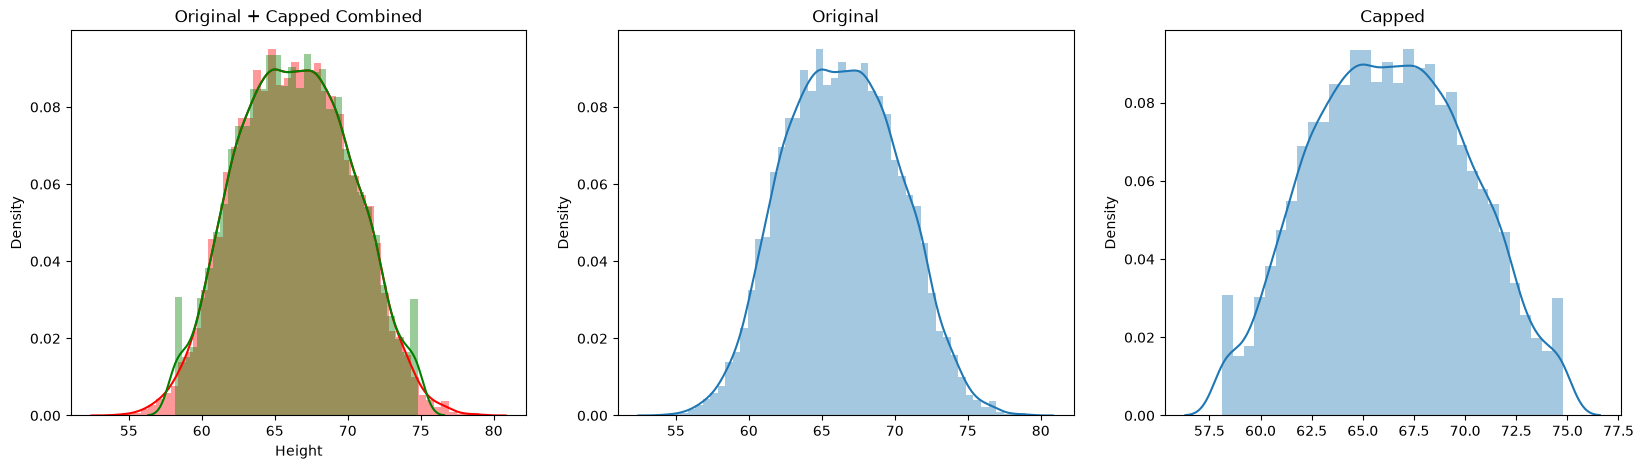

In [59]:
plt.figure(figsize= (20, 5))

plt.subplot(131)
plt.title("Original + Capped Combined")
sns.distplot(gwh["Height"], color= "red", hist= True)
sns.distplot(capped_gwh["Height"], color= "green", hist= True)

plt.subplot(132)
plt.title("Original")
sns.distplot(x= gwh["Height"])

plt.subplot(133)
plt.title("Capped")
sns.distplot(x= capped_gwh["Height"])

<Axes: title={'center': 'Capped'}, xlabel='Height'>

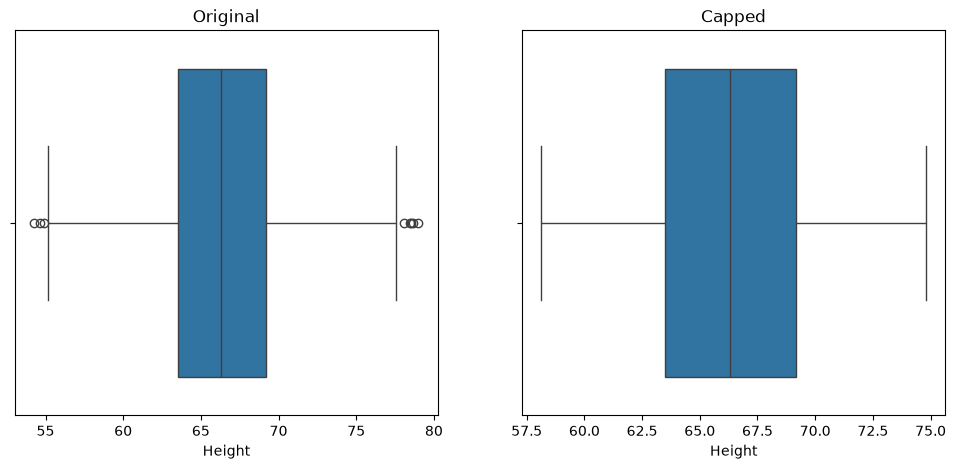

In [60]:
plt.figure(figsize= (12, 5))

plt.subplot(121)
plt.title("Original")
sns.boxplot(x= gwh["Height"])

plt.subplot(122)
plt.title("Capped")
sns.boxplot(x= capped_gwh["Height"])

### ALL FOUR PDFs

C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\3470881821.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gwh["Height"], color= "red", hist= True)
C:\Users\aliab\AppData\Local\Temp\ipykernel_12824\3470881821.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(trimmed_gwh["Height"], color=

<Axes: title={'center': 'Capped'}, ylabel='Density'>

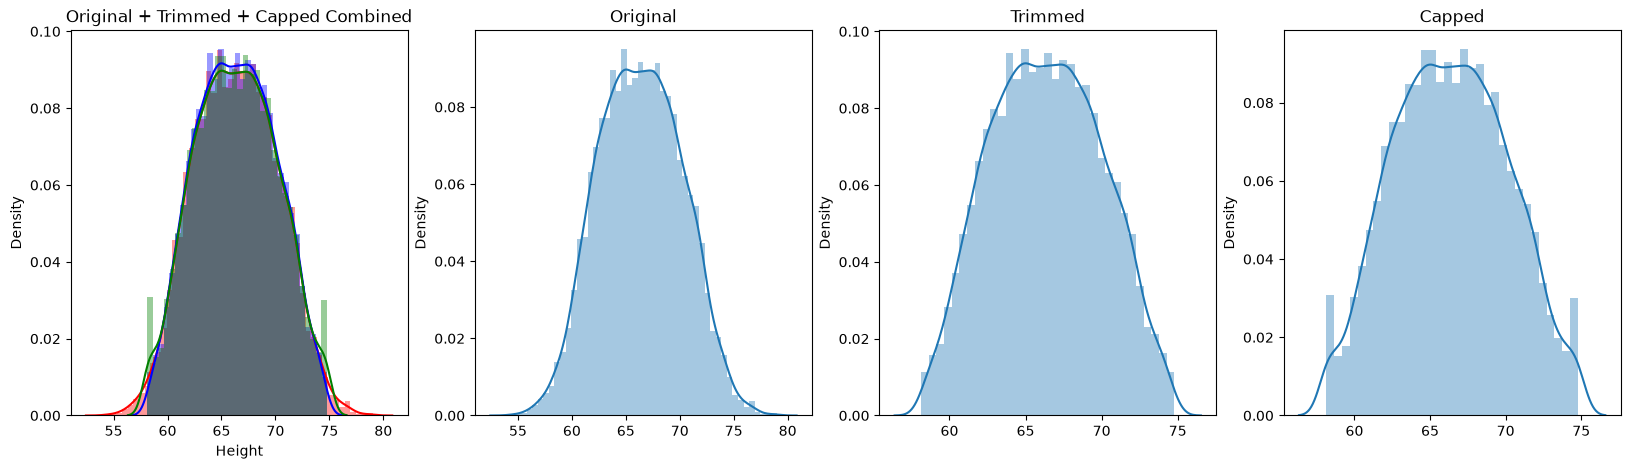

In [61]:
plt.figure(figsize= (20, 5))

plt.subplot(141)
plt.title("Original + Trimmed + Capped Combined")
sns.distplot(gwh["Height"], color= "red", hist= True)
sns.distplot(trimmed_gwh["Height"], color= "blue", hist= True)
sns.distplot(capped_gwh["Height"], color= "green", hist= True)

plt.subplot(142)
plt.title("Original")
sns.distplot(x= gwh["Height"])

plt.subplot(143)
plt.title("Trimmed")
sns.distplot(x= trimmed_gwh["Height"])

plt.subplot(144)
plt.title("Capped")
sns.distplot(x= capped_gwh["Height"])